In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
print("✅ Imports done!")

✅ Imports done!


In [3]:
rf_model  = joblib.load(r"C:\Users\Gazala Anjum B K\Documents\cyber threat detection\cyber-threat-detection\models\random_forest.pkl")
xgb_model = joblib.load(r"C:\Users\Gazala Anjum B K\Documents\cyber threat detection\cyber-threat-detection\models\xgboost.pkl")
df = pd.read_csv(r"C:\Users\Gazala Anjum B K\Documents\cyber threat detection\cyber-threat-detection\data\features.csv")
X = df.drop("label", axis=1)
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
with open(r"C:\Users\Gazala Anjum B K\Documents\cyber threat detection\cyber-threat-detection\models\ensemble_config.json") as f:
    config = json.load(f)
RF_WEIGHT  = config["rf_weight"]
XGB_WEIGHT = config["xgb_weight"]
rf_proba       = rf_model.predict_proba(X_test)[:, 1]
xgb_proba      = xgb_model.predict_proba(X_test)[:, 1]
ensemble_proba = RF_WEIGHT * rf_proba + XGB_WEIGHT * xgb_proba
ensemble_pred  = (ensemble_proba >= 0.5).astype(int)
print(f"✅ Loaded! Accuracy: {accuracy_score(y_test, ensemble_pred)*100:.2f}%")

✅ Loaded! Accuracy: 95.46%


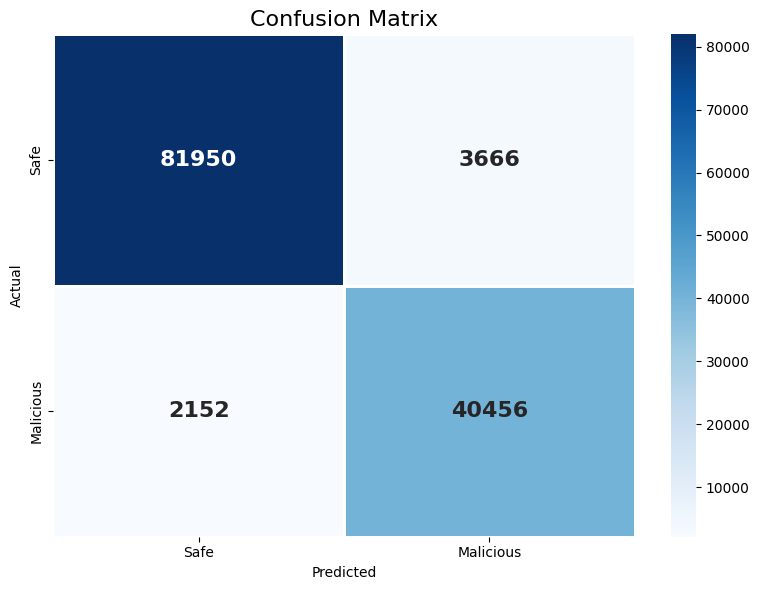

TP: 40456 | TN: 81950 | FP: 3666 | FN: 2152


In [4]:
cm = confusion_matrix(y_test, ensemble_pred)
tn, fp, fn, tp = cm.ravel()
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Safe","Malicious"], yticklabels=["Safe","Malicious"], linewidths=2, annot_kws={"size":16,"weight":"bold"})
plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(r"C:\Users\Gazala Anjum B K\Documents\cyber threat detection\cyber-threat-detection\data\confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")

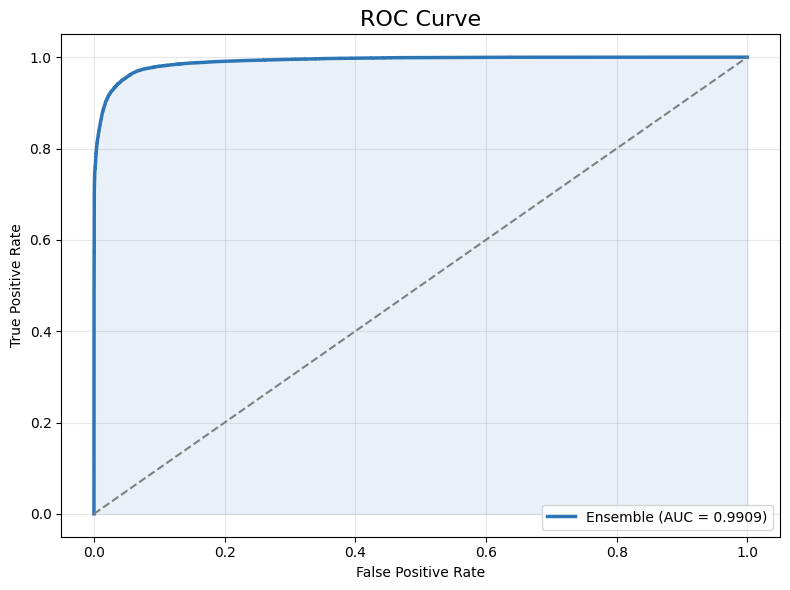

AUC: 0.9909


In [5]:
fpr, tpr, _ = roc_curve(y_test, ensemble_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#2E75B6", linewidth=2.5, label=f"Ensemble (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1], color="gray", linestyle="--")
plt.fill_between(fpr, tpr, alpha=0.1, color="#2E75B6")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve", fontsize=16)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\Gazala Anjum B K\Documents\cyber threat detection\cyber-threat-detection\data\roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC: {roc_auc:.4f}")

In [6]:
accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
print("=" * 40)
print("   FINAL EVALUATION SUMMARY")
print("=" * 40)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}")
metrics = {"accuracy": round(accuracy,4), "precision": round(precision,4), "recall": round(recall,4), "f1_score": round(f1,4), "auc_roc": round(roc_auc,4)}
with open(r"C:\Users\Gazala Anjum B K\Documents\cyber threat detection\cyber-threat-detection\models\metrics.json","w") as f:
    json.dump(metrics, f, indent=2)
print("\n✅ STEP 7 COMPLETE!")

   FINAL EVALUATION SUMMARY
Accuracy:  95.46%
Precision: 91.69%
Recall:    94.95%
F1 Score:  0.9329
AUC-ROC:   0.9909

✅ STEP 7 COMPLETE!
